# 01 — Exploratory Data Analysis
**Goal:** Understand the shape, size, and content of the raw Medicaid dataset before any cleaning.

**Key Questions:**
- How many rows and columns are there?
- What are the data types?
- What is the date range?
- How many unique providers and HCPCS codes exist?
- What does the spending distribution look like?

In [1]:
import duckdb
import polars as pl
import os

con = duckdb.connect()

parquet_path = os.path.expanduser('~/Downloads/medicaid-provider-spending.parquet')
csv_path = '/Users/adilkassim/Downloads/NPPES_Data_Dissemination_February_2026_V2/npidata_pfile_20050523-20260208.csv'

con.execute(f"CREATE VIEW medicaid AS SELECT * FROM read_parquet('{parquet_path}')")
con.execute(f"CREATE OR REPLACE VIEW provider_info_raw AS SELECT * FROM read_csv_auto('{csv_path}', all_varchar=1)")

## 1. Schema & Data Types

In [3]:
con.sql("DESCRIBE medicaid").pl()

column_name,column_type,null,key,default,extra
str,str,str,str,str,str
"""BILLING_PROVIDER_NPI_NUM""","""VARCHAR""","""YES""",null,null,null
"""SERVICING_PROVIDER_NPI_NUM""","""VARCHAR""","""YES""",null,null,null
"""HCPCS_CODE""","""VARCHAR""","""YES""",null,null,null
"""CLAIM_FROM_MONTH""","""VARCHAR""","""YES""",null,null,null
"""TOTAL_UNIQUE_BENEFICIARIES""","""BIGINT""","""YES""",null,null,null
"""TOTAL_CLAIMS""","""BIGINT""","""YES""",null,null,null
"""TOTAL_PAID""","""DOUBLE""","""YES""",null,null,null


## 2. Row Count & Date Range

In [4]:
con.sql("""
    SELECT
        COUNT(*)                        AS total_rows,
        COUNT(DISTINCT HCPCS_CODE)      AS unique_hcpcs,
        COUNT(DISTINCT BILLING_PROVIDER_NPI_NUM) AS unique_providers,
        MIN(CLAIM_FROM_MONTH)           AS earliest_month,
        MAX(CLAIM_FROM_MONTH)           AS latest_month
    FROM medicaid
""").pl()

total_rows,unique_hcpcs,unique_providers,earliest_month,latest_month
i64,i64,i64,str,str
227083361,10881,617503,"""2018-01""","""2024-12"""


## 3. Spending Distribution

In [ ]:
con.sql("""
    SELECT
        MIN(TOTAL_PAID)    AS min_paid,
        MAX(TOTAL_PAID)    AS max_paid,
        AVG(TOTAL_PAID)    AS avg_paid,
        MEDIAN(TOTAL_PAID) AS median_paid,
        SUM(TOTAL_PAID)    AS total_paid
    FROM medicaid
""").pl()

min_paid,max_paid,avg_paid,median_paid,total_paid
f64,f64,f64,f64,f64
-183021.84,1.1889e8,4815.688955,616.39,1.0936e12


In [ ]:
## Shouldn't be any negatives
## Let's check how many there are

con.sql("""
    SELECT *
    FROM medicaid
    WHERE TOTAL_CLAIMS = 0
""")


┌──────────────────────────┬────────────────────────────┬────────────┬──────────────────┬────────────────────────────┬──────────────┬────────────┐
│ BILLING_PROVIDER_NPI_NUM │ SERVICING_PROVIDER_NPI_NUM │ HCPCS_CODE │ CLAIM_FROM_MONTH │ TOTAL_UNIQUE_BENEFICIARIES │ TOTAL_CLAIMS │ TOTAL_PAID │
│         varchar          │          varchar           │  varchar   │     varchar      │           int64            │    int64     │   double   │
├──────────────────────────┴────────────────────────────┴────────────┴──────────────────┴────────────────────────────┴──────────────┴────────────┤
│                                                                     0 rows                                                                     │
└────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

## 4. Top 20 HCPCS Codes by Volume

In [6]:
con.sql("""
    SELECT HCPCS_CODE, COUNT(*) AS row_count, SUM(TOTAL_PAID) AS total_paid
    FROM medicaid
    GROUP BY HCPCS_CODE
    ORDER BY row_count DESC
    LIMIT 20
""").pl()

HCPCS_CODE,row_count,total_paid
str,i64,f64
"""99213""",13566914,3.3003e10
"""99214""",11728025,2.9914e10
"""99284""",3980198,2.0152e10
"""99283""",3270001,1.6875e10
"""99285""",2901462,1.5097e10
…,…,…
"""93010""",1606947,4.8772e8
"""D1110""",1598227,2.5378e9
"""99203""",1543645,3.2258e9


## 5. Spending by Year (Quick Plot)

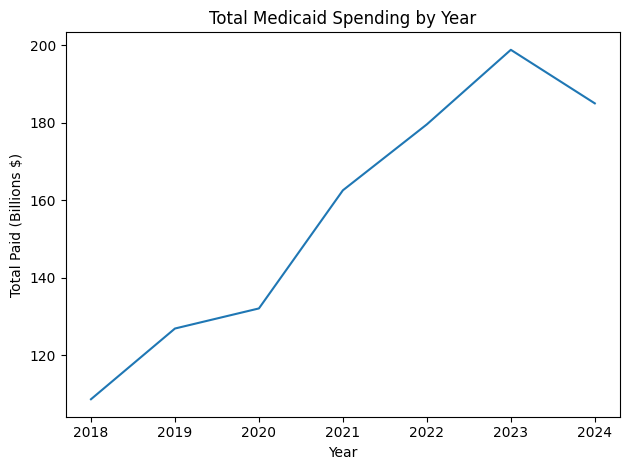

In [11]:
import matplotlib.pyplot as plt

df_yearly = con.sql("""
    SELECT
        SUBSTR(CLAIM_FROM_MONTH, 1, 4) AS year,
        SUM(TOTAL_PAID) / 1e9          AS total_paid_billions
    FROM medicaid
    GROUP BY year
    ORDER BY year
""").df()

ax = df_yearly.plot(kind='line', x='year', y='total_paid_billions',
                    title='Total Medicaid Spending by Year', legend=False)
ax.set_ylabel('Total Paid (Billions $)')
ax.set_xlabel('Year')
plt.tight_layout()
plt.show()